# Interface S-Matrix for a Rib Waveguide Step — From First Principles

This notebook derives the interface scattering matrix for a step discontinuity
between two rib waveguides, starting from Maxwell's equations.
We identify the correct inner product, derive the interface formulas,
discuss when a metric correction is needed, and validate against a reference.

## 1. Mode Expansion and Boundary Conditions

In a $z$-invariant waveguide, the transverse electromagnetic fields are expanded in eigenmodes:

$$\mathbf{E}_t(x,y,z) = \sum_p \bigl[\, a_p^{+}\, e^{-j\beta_p z} \;+\; a_p^{-}\, e^{+j\beta_p z}\bigr]\, \mathbf{e}_p(x,y)$$

$$\mathbf{H}_t(x,y,z) = \sum_p \bigl[\, a_p^{+}\, e^{-j\beta_p z} \;-\; a_p^{-}\, e^{+j\beta_p z}\bigr]\, \mathbf{h}_p(x,y)$$

The **sign flip** on $\mathbf{H}_t$ for backward-propagating modes comes from Maxwell's curl equation: a mode traveling in $-z$ has $\mathbf{H}_t \to -\mathbf{H}_t$ relative to $\mathbf{E}_t$.

At an interface ($z = 0$) between medium L (left) and medium R (right), tangential field continuity demands:

$$\sum_p (a_p^{+} + a_p^{-})\,\mathbf{e}_p^L \;=\; \sum_q (b_q^{+} + b_q^{-})\,\mathbf{e}_q^R \qquad \text{(E continuity)}$$

$$\sum_p (a_p^{+} - a_p^{-})\,\mathbf{h}_p^L \;=\; \sum_q (b_q^{+} - b_q^{-})\,\mathbf{h}_q^R \qquad \text{(H continuity)}$$

where $a^+, a^-$ are forward/backward amplitudes in medium L and $b^+, b^-$ in medium R.

## 2. The Asymmetric Inner Product

To convert the vector continuity equations into a matrix system, we project them
onto test functions. The natural choice is the **asymmetric Poynting overlap**:

$$\langle \mathbf{e}_a,\, \mathbf{h}_b \rangle \;=\; \frac{1}{2}\int_S (\mathbf{e}_a \times \mathbf{h}_b)\cdot\hat{z}\; dA$$

This is **not** symmetric in its arguments: $\langle \mathbf{e}_a, \mathbf{h}_b \rangle \neq \langle \mathbf{e}_b, \mathbf{h}_a \rangle$ for modes of *different* waveguides.

Define the overlap and metric matrices:

| Matrix | Definition | Meaning |
|--------|-----------|---------|
| $O_{LR}[i,j]$ | $\langle \mathbf{e}_i^L,\, \mathbf{h}_j^R \rangle$ | cross-overlap, left E with right H |
| $O_{RL}[i,j]$ | $\langle \mathbf{e}_i^R,\, \mathbf{h}_j^L \rangle$ | cross-overlap, right E with left H |
| $G_{LL}[i,j]$ | $\langle \mathbf{e}_i^L,\, \mathbf{h}_j^L \rangle$ | self-overlap (metric) for left modes |
| $G_{RR}[i,j]$ | $\langle \mathbf{e}_i^R,\, \mathbf{h}_j^R \rangle$ | self-overlap (metric) for right modes |

**Key properties** (for lossless waveguides, unconjugated product):
- **Lorentz reciprocity within the same waveguide**: $\langle \mathbf{e}_i, \mathbf{h}_j \rangle = \langle \mathbf{e}_j, \mathbf{h}_i \rangle$, so $G_{LL} = G_{LL}^T$ and $G_{RR} = G_{RR}^T$.
- **Mode orthogonality**: modes with distinct $\beta$ satisfy $\langle \mathbf{e}_i, \mathbf{h}_j \rangle = 0$ for $i \neq j$.
- **No cross-waveguide reciprocity**: $O_{LR} \neq O_{RL}^T$ in general (different waveguide geometries break the Lorentz relation).

For **orthonormalized** modes: $G_{LL} = G_{RR} = I$.

### Why not the symmetric product?

The *symmetric* (Tidy3D-style) inner product is defined as:

$$\langle \mathbf{e}_a,\, \mathbf{h}_b \rangle_{\text{sym}} = \frac{1}{4}\int_S \bigl[(\mathbf{e}_a \times \mathbf{h}_b) + (\mathbf{e}_b \times \mathbf{h}_a)\bigr]\cdot\hat{z}\; dA$$

By construction this is **commutative**: $\langle \mathbf{e}_a, \mathbf{h}_b \rangle_{\text{sym}} = \langle \mathbf{e}_b, \mathbf{h}_a \rangle_{\text{sym}}$ for *any* two modes (same or different waveguide). This forces $O_{LR} = O_{RL}^T$ identically, which makes $O_{RL}^T - O_{LR} = 0$ and therefore **$R = 0$ always** — the reflection information is algebraically destroyed.

**The asymmetric product is essential** for capturing interface reflection.


## 3. Deriving the Interface Matrices

### Left incidence ($\mathbf{b}^- = 0$)

We project **E-continuity** with $\mathbf{h}_k^L$ and **H-continuity** with $\mathbf{e}_k^L$:

$$\text{(E):}\quad G_{LL}(\mathbf{a}^+ + \mathbf{a}^-) = O_{RL}^T\,\mathbf{b}^+$$
$$\text{(H):}\quad G_{LL}(\mathbf{a}^+ - \mathbf{a}^-) = O_{LR}\,\mathbf{b}^+$$

Adding gives

$$2G_{LL}\mathbf{a}^+ = (O_{LR}+O_{RL}^T)\mathbf{b}^+,$$
$$\boxed{T_{LR}=2\,(O_{LR}+O_{RL}^T)^{-1}G_{LL}}.$$

Subtracting gives the standard reflection form

$$\boxed{R_{LL}=\tfrac{1}{2}G_{LL}^{-1}(O_{RL}^T-O_{LR})T_{LR}}.$$

For orthonormal modes ($G_{LL}=I$), E/H continuity also gives two numerically useful equivalent forms:

$$\boxed{R_{LL}=O_{RL}^T T_{LR}-I = I-O_{LR}T_{LR}}.$$

Averaging these two recovers the standard difference form:

$$\tfrac{1}{2}\left[(O_{RL}^TT_{LR}-I) + (I-O_{LR}T_{LR})\right]
= \tfrac{1}{2}(O_{RL}^T-O_{LR})T_{LR}.$$

In this notebook we solve for $T$ with a TSVD-regularized pseudoinverse:

$$T_{LR}=2\,(O_{LR}+O_{RL}^T)_{\text{TSVD}}^{+}.$$



### Right incidence ($\mathbf{a}^+ = 0$)

Projecting with medium-R test functions ($\mathbf{h}_k^R$ for E, $\mathbf{e}_k^R$ for H):

$$G_{RR}(\mathbf{b}^+ + \mathbf{b}^-) = O_{LR}^T\,\mathbf{a}^-$$
$$G_{RR}(\mathbf{b}^+ - \mathbf{b}^-) = -O_{RL}\,\mathbf{a}^-$$

Hence

$$\boxed{T_{RL}=2\,(O_{RL}+O_{LR}^T)^{-1}G_{RR}},$$
$$\boxed{R_{RR}=\tfrac{1}{2}G_{RR}^{-1}(O_{LR}^T-O_{RL})T_{RL}}.$$

For orthonormal modes ($G_{RR}=I$), the equivalent continuity forms are

$$\boxed{R_{RR}=O_{LR}^T T_{RL}-I = I-O_{RL}T_{RL}}.$$

### Full two-port S-matrix

Assembling into $[\mathbf{a}^-;\mathbf{b}^+] = S[\mathbf{a}^+;\mathbf{b}^-]$:

$$S = \begin{pmatrix} R_{LL} & T_{RL} \\ T_{LR} & R_{RR} \end{pmatrix}$$


## 4. On the Metric

The matrix $G_{LL}$ (or $G_{RR}$) plays the role of a **metric tensor** in the mode-amplitude space.

**When can we ignore it?** If modes are orthonormalized with respect to the asymmetric product,
then $G = I$ and the metric factors drop out. This is the simplest and most robust approach.

**When is it needed?** If modes are *not* orthonormalized (e.g., raw eigensolver output), $G \neq I$
and the metric factors must be included. The generalized formulas from Section 3 handle this correctly.

**Passivity**: for a lossless interface, energy conservation requires $S^\dagger G_{\text{out}}\, S \leq G_{\text{in}}$
where $G_{\text{in}} = G_{\text{out}} = \text{diag}(G_{LL},\, G_{RR})$ in the block ordering above.
With orthonormal modes, this simplifies to $S^\dagger S \leq I$ (singular values $\leq 1$).

**Recommendation**: orthonormalize the modes first, then use the simple formulas. This avoids
ill-conditioned metric inversions and keeps the S-matrix interpretation clean.

## 5. Sanity Checks (Analytical)

**Same-medium test** ($L = R$): with $O_{LR} = O_{RL} = G$ and orthonormal modes ($G = I$):

$$T = 2(I + I)^{-1} = I, \qquad R = \tfrac{1}{2}(I - I)\,I = 0 \qquad \checkmark$$

**Fresnel limit** (single mode, homogeneous media): for a plane wave at normal incidence,
the overlap integrals reduce to $O_{LR} = \sqrt{n_R/n_L}$ and $O_{RL} = \sqrt{n_L/n_R}$
(with normalized modes). Then:

$$T = \frac{2}{\sqrt{n_R/n_L} + \sqrt{n_L/n_R}} = \frac{2\sqrt{n_L n_R}}{n_L + n_R}$$

$$R = \frac{\sqrt{n_L/n_R} - \sqrt{n_R/n_L}}{\sqrt{n_R/n_L} + \sqrt{n_L/n_R}} = \frac{n_L - n_R}{n_L + n_R}$$

which recovers the Fresnel equations (in mode-amplitude convention). $\checkmark$

---
## 6. Implementation

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import meow as mw
import numpy as np
from meow.mode import energy_density

### 6.1 Geometry (same rib waveguide step as previous notebooks)

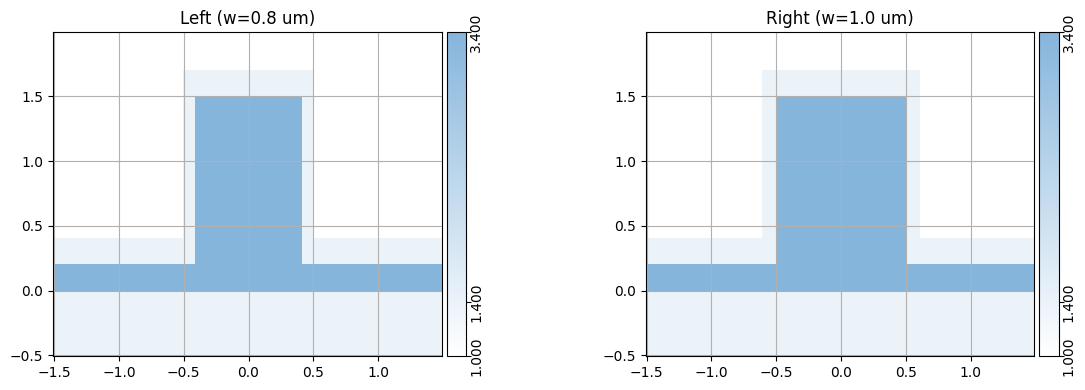

In [2]:
wl = 1.0
widths = [0.8, 1.0]
t_slab, t_soi, t_ox = 0.2, 1.5, 0.2
n_Si, n_SiO2 = 3.4, 1.4
w_sim, h_sim, y_bot = 3.0, 2.5, -0.5

si = mw.IndexMaterial(n=n_Si, name="Si", meta={"color": "orange"})
sio2 = mw.IndexMaterial(n=n_SiO2, name="SiO2", meta={"color": "steelblue"})

env = mw.Environment(wl=wl, T=25.0)
mesh = mw.Mesh2D(
    x=np.linspace(-w_sim / 2, w_sim / 2, 101),
    y=np.linspace(y_bot, y_bot + h_sim, 101),
    #num_pml=(10, 10),
)


def make_cross_section(w):
    structures = [
        mw.Structure2D(
            material=sio2,
            geometry=mw.Rectangle(
                x_min=-w_sim / 2,
                x_max=w_sim / 2,
                y_min=y_bot,
                y_max=t_slab + t_ox,
            ),
            mesh_order=2,
        ),
        mw.Structure2D(
            material=sio2,
            geometry=mw.Rectangle(
                x_min=-w / 2 - t_ox / 2,
                x_max=w / 2 + t_ox / 2,
                y_min=t_slab + t_ox,
                y_max=t_soi + t_ox,
            ),
            mesh_order=2,
        ),
        mw.Structure2D(
            material=si,
            geometry=mw.Rectangle(
                x_min=-w_sim / 2,
                x_max=w_sim / 2,
                y_min=0.0,
                y_max=t_slab,
            ),
            mesh_order=1,
        ),
        mw.Structure2D(
            material=si,
            geometry=mw.Rectangle(
                x_min=-w / 2,
                x_max=w / 2,
                y_min=t_slab,
                y_max=t_soi,
            ),
            mesh_order=1,
        ),
    ]
    return mw.CrossSection(
        structures=structures,
        mesh=mesh,
        env=env,
        subpixel_smoothing=True,
    )


cs_left = make_cross_section(widths[0])
cs_right = make_cross_section(widths[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cs_left._visualize(ax=axes[0], show=False)
axes[0].set_title(f"Left (w={widths[0]} um)")
cs_right._visualize(ax=axes[1], show=False)
axes[1].set_title(f"Right (w={widths[1]} um)")
plt.tight_layout()
plt.show()


### 6.2 Minimal mode pipeline (required vs optional)

Required for this notebook:
1. Compute modes (`compute_modes`)
2. Orthonormalize with the chosen inner product (`orthonormalize_strict`)
3. Build overlaps and solve for $T$, then $R$, then $S$

Optional (recommended when PML or lossy/complex modes are present):
- filter modes by forward power / PML fraction / attenuation before orthonormalization

Notes:
- `compute_modes` already normalizes each raw mode, but this does **not** guarantee mutual orthogonality.
- strict orthonormalization is still needed because the interface formulas assume an orthonormal basis ($G\approx I$).


In [3]:
# Asymmetric, unconjugated Poynting inner product: 1/2 ∫ (E1 x H2) · z_hat dA
ip = partial(mw.inner_product, symmetric=False, conjugate=False)

num_modes = 100

modes_left_raw = mw.compute_modes(cs_left, num_modes=num_modes, inner_product=ip)
modes_right_raw = mw.compute_modes(cs_right, num_modes=num_modes, inner_product=ip)
print(f"Raw modes: {len(modes_left_raw)} left, {len(modes_right_raw)} right")

# Optional pre-filtering (mainly useful with PML / complex modes).
use_filter = any(cs_left.mesh.num_pml) or any(cs_right.mesh.num_pml)

if use_filter:
    ip_conj = partial(mw.inner_product, symmetric=False, conjugate=True)

    def pml_fraction(mode):
        """Fraction of energy density in the PML region."""
        numx, numy = mode.mesh.num_pml
        ed = np.real(energy_density(mode))
        m, n = ed.shape
        lft = ed[:numx, :]
        rgt = ed[m - numx :, :]
        top = ed[numx : m - numx, :numy]
        btm = ed[numx : m - numx, n - numy :]
        rest = ed[numx : m - numx, numy : n - numy]
        pml_sum = lft.sum() + rgt.sum() + top.sum() + btm.sum()
        total = pml_sum + rest.sum()
        return float(pml_sum / total) if total > 0 else 1.0

    def filter_modes(modes, ip_conj, P_min=1e-2, f_pml_max=0.1, alpha_max=1.0):
        kept = []
        reasons = {"power": 0, "pml": 0, "attn": 0}
        for m in modes:
            if np.real(ip_conj(m, m)) < P_min:
                reasons["power"] += 1
                continue
            if pml_fraction(m) > f_pml_max:
                reasons["pml"] += 1
                continue
            if abs(np.imag(m.neff)) > alpha_max:
                reasons["attn"] += 1
                continue
            kept.append(m)
        print(
            f"  Kept {len(kept)}/{len(modes)} -- rejected: "
            f"{reasons['power']} (low power), {reasons['pml']} (PML), "
            f"{reasons['attn']} (high attn)"
        )
        return kept

    print("Filtering left modes:")
    modes_left_in = filter_modes(modes_left_raw, ip_conj)
    print("Filtering right modes:")
    modes_right_in = filter_modes(modes_right_raw, ip_conj)
else:
    print("Filtering skipped (no PML configured).")
    modes_left_in = modes_left_raw
    modes_right_in = modes_right_raw


def orthonormalize_strict(modes, ip, tol=1e-2):
    """Gram-Schmidt orthonormalization with drop tolerance."""
    if not modes:
        return []
    basis = []
    n_dropped = 0
    for mode in modes:
        current = mode
        for b in basis:
            current = current - (ip(b, current) / ip(b, b)) * b
        norm_sq = ip(current, current)
        if np.abs(norm_sq) < tol:
            n_dropped += 1
            continue
        basis.append(current / np.sqrt(norm_sq))
    print(
        f"  Orthonormalized: {len(basis)} kept, {n_dropped} dropped (residual < {tol})"
    )
    return basis


print("Orthonormalizing left modes:")
modes_left = orthonormalize_strict(modes_left_in, ip)
print("Orthonormalizing right modes:")
modes_right = orthonormalize_strict(modes_right_in, ip)

Raw modes: 100 left, 100 right
Filtering skipped (no PML configured).
Orthonormalizing left modes:
  Orthonormalized: 100 kept, 0 dropped (residual < 0.01)
Orthonormalizing right modes:
  Orthonormalized: 100 kept, 0 dropped (residual < 0.01)


Left cross-section modes


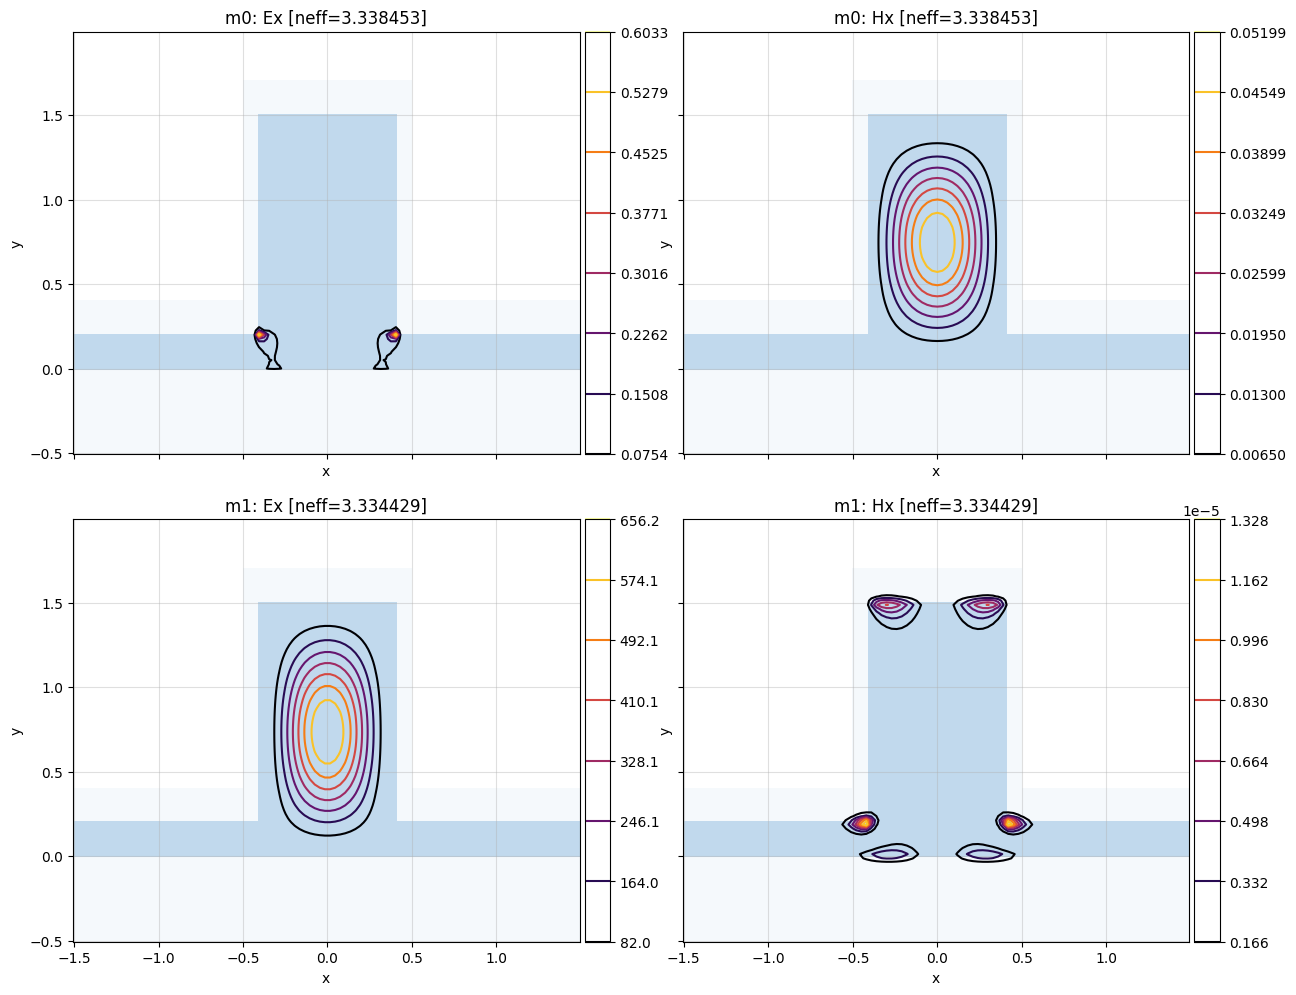

Right cross-section modes


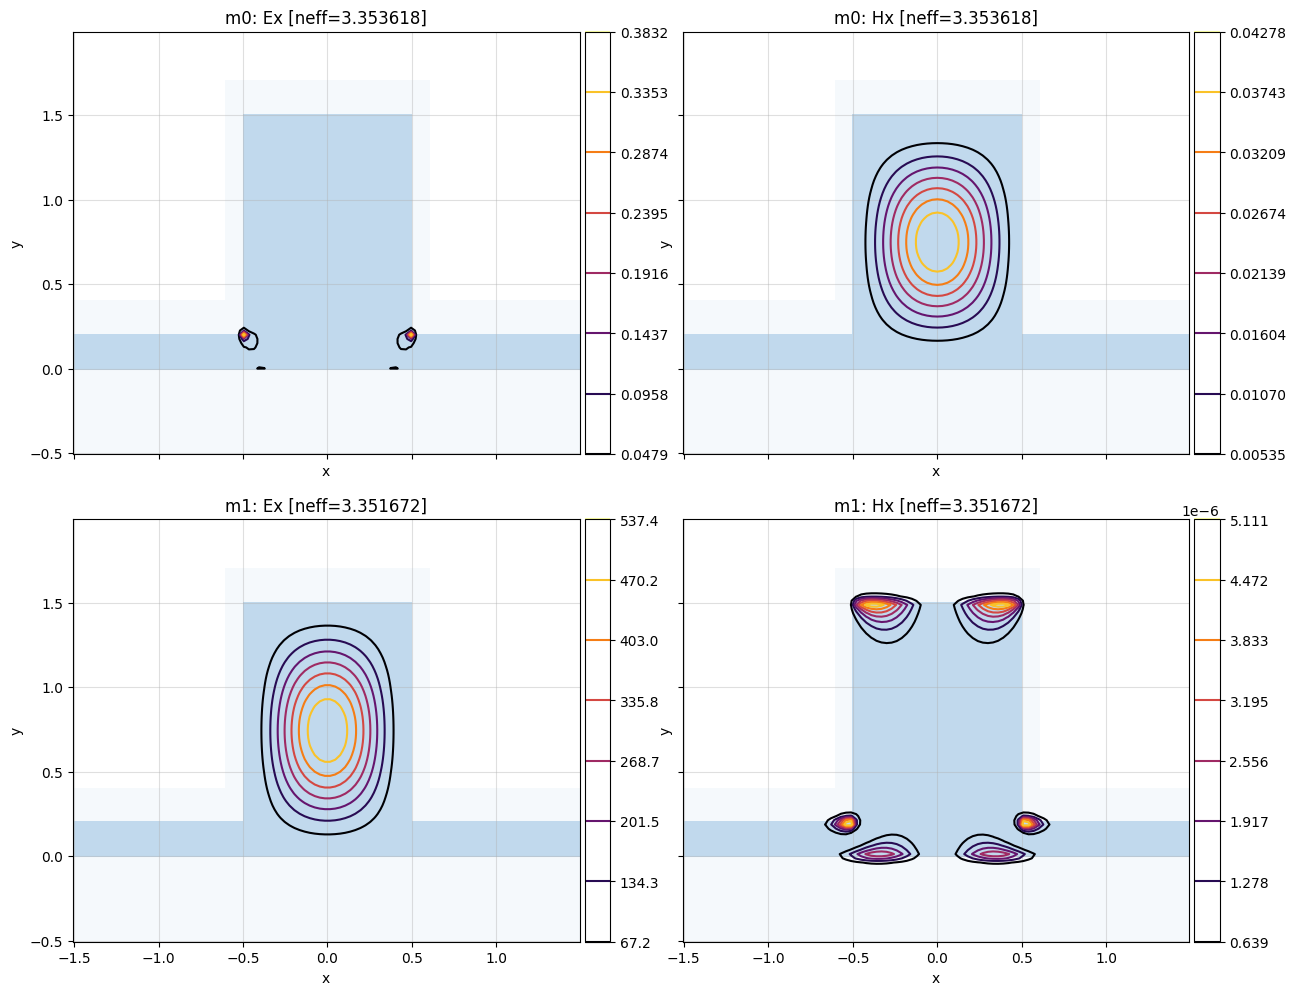

In [4]:
# Visualize left and right mode sets
print("Left cross-section modes")
mw.visualize(modes_left[:2], fields=("Ex", "Hx"))

print("Right cross-section modes")
mw.visualize(modes_right[:2], fields=("Ex", "Hx"))

In [5]:
# Verify orthonormality: G_LL and G_RR should be ≈ I
def overlap_matrix(modes_a, modes_b, op):
    M = np.zeros((len(modes_a), len(modes_b)), dtype=np.complex128)
    for i, ma in enumerate(modes_a):
        for j, mb in enumerate(modes_b):
            M[i, j] = op(ma, mb)
    return M


N = min(len(modes_left), len(modes_right))
mL = modes_left[:N]
mR = modes_right[:N]

G_LL = overlap_matrix(mL, mL, ip)
G_RR = overlap_matrix(mR, mR, ip)
I = np.eye(N)

print(f"N = {N}")
print(f"||G_LL - I||_F = {np.linalg.norm(G_LL - I):.3e}")
print(f"||G_RR - I||_F = {np.linalg.norm(G_RR - I):.3e}")

N = 100
||G_LL - I||_F = 6.568e-02
||G_RR - I||_F = 3.965e-02



### 6.3 Build overlap matrices and compute the regularized interface S-matrix


In [6]:
# Cross-overlap matrices (asymmetric product -> O_LR != O_RL^T in general)
O_LR = overlap_matrix(mL, mR, ip)
O_RL = overlap_matrix(mR, mL, ip)

print(
    f"||O_LR - O_RL^T||_F = {np.linalg.norm(O_LR - O_RL.T):.6f}  (should be nonzero!)"
)
print(f"||O_LR||_F = {np.linalg.norm(O_LR):.6f}")


# TSVD-regularized linear solve for better numerical stability.
# We use a relative cutoff: s_cut = rcond * s_max.
def tsvd_solve(A, B, rcond=1e-5):
    U, s, Vh = np.linalg.svd(A, full_matrices=False)
    s_cut = rcond * s[0] if s.size else 0.0
    keep = s >= s_cut
    if not np.any(keep):
        msg = "TSVD rejected all singular values; lower rcond."
        raise RuntimeError(msg)
    A_pinv = (Vh.conj().T[:, keep] * (1.0 / s[keep])) @ U.conj().T[keep, :]
    X = A_pinv @ B
    return X, s, s_cut, int(np.count_nonzero(keep))


# Interface matrices (orthonormal modes -> G = I)
# T_LR = 2 * (O_LR + O_RL^T)^(-1), solved via TSVD pseudoinverse.
rcond_tsvd = 1e-1
I_N = np.eye(N)

A_LR = O_LR + O_RL.T
T_LR, s_LR, s_cut_LR, rank_LR = tsvd_solve(A_LR, 2.0 * I_N, rcond=rcond_tsvd)

A_RL = O_RL + O_LR.T
T_RL, s_RL, s_cut_RL, rank_RL = tsvd_solve(A_RL, 2.0 * I_N, rcond=rcond_tsvd)

# Compute R from both continuity equations and average; this reduces sensitivity
# to cancellation relative to directly forming (O_RL^T - O_LR).
R_LL_e = O_RL.T @ T_LR - I_N
R_LL_h = I_N - O_LR @ T_LR
R_LL = 0.5 * (R_LL_e + R_LL_h)

R_RR_e = O_LR.T @ T_RL - I_N
R_RR_h = I_N - O_RL @ T_RL
R_RR = 0.5 * (R_RR_e + R_RR_h)

# Full S-matrix: [a-; b+] = S [a+; b-]
S = np.block(
    [
        [R_LL, T_RL],
        [T_LR, R_RR],
    ]
)

print(f"\nInterface S-matrix shape: {S.shape}")
print(f"rcond_tsvd = {rcond_tsvd:.1e}")
print(f"cond(A_LR) = {np.linalg.cond(A_LR):.3e}")
print(
    f"  s_max(A_LR) = {s_LR[0]:.3e}, s_min(A_LR) = {s_LR[-1]:.3e}, s_cut = {s_cut_LR:.3e}"
)
print(f"  kept singular values: {rank_LR}/{N}")
print(f"cond(A_RL) = {np.linalg.cond(A_RL):.3e}")
print(
    f"  s_max(A_RL) = {s_RL[0]:.3e}, s_min(A_RL) = {s_RL[-1]:.3e}, s_cut = {s_cut_RL:.3e}"
)
print(f"  kept singular values: {rank_RL}/{N}")
print(f"|T_LR[0,0]| = {abs(T_LR[0, 0]):.6f}")
print(f"|R_LL[0,0]| = {abs(R_LL[0, 0]):.6f}")
print(f"|T_RL[0,0]| = {abs(T_RL[0, 0]):.6f}")
print(f"|R_RR[0,0]| = {abs(R_RR[0, 0]):.6f}")

||O_LR - O_RL^T||_F = 0.913739  (should be nonzero!)
||O_LR||_F = 9.531532

Interface S-matrix shape: (200, 200)
rcond_tsvd = 1.0e-01
cond(A_LR) = 2.629e+05
  s_max(A_LR) = 2.030e+00, s_min(A_LR) = 7.721e-06, s_cut = 2.030e-01
  kept singular values: 96/100
cond(A_RL) = 2.629e+05
  s_max(A_RL) = 2.030e+00, s_min(A_RL) = 7.721e-06, s_cut = 2.030e-01
  kept singular values: 96/100
|T_LR[0,0]| = 0.986003
|R_LL[0,0]| = 0.000822
|T_RL[0,0]| = 0.986003
|R_RR[0,0]| = 0.006086


/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:20: RuntimeWarning: divide by zero encountered in matmul
  A_pinv = (Vh.conj().T[:, keep] * (1.0 / s[keep])) @ U.conj().T[keep, :]
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:20: RuntimeWarning: overflow encountered in matmul
  A_pinv = (Vh.conj().T[:, keep] * (1.0 / s[keep])) @ U.conj().T[keep, :]
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:20: RuntimeWarning: invalid value encountered in matmul
  A_pinv = (Vh.conj().T[:, keep] * (1.0 / s[keep])) @ U.conj().T[keep, :]
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:21: RuntimeWarning: divide by zero encountered in matmul
  X = A_pinv @ B
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:21: RuntimeWarning: overflow encountered in matmul
  X = A_pinv @ B
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:21: 

### 6.4 Sanity checks

In [7]:
# Same-medium check: L->L should give T=I, R=0
O_ll = overlap_matrix(mL, mL, ip)
A_ll = O_ll + O_ll.T
T_ll, _s_ll, _s_cut_ll, _rank_ll = tsvd_solve(A_ll, 2.0 * np.eye(N), rcond=rcond_tsvd)
R_ll_e = O_ll.T @ T_ll - np.eye(N)
R_ll_h = np.eye(N) - O_ll @ T_ll
R_ll_self = 0.5 * (R_ll_e + R_ll_h)

print("Same-medium sanity check (L->L):")
print(f"  ||T_LL - I||_F = {np.linalg.norm(T_ll - I):.3e}")
print(f"  ||R_LL||_F     = {np.linalg.norm(R_ll_self):.3e}")

# Passivity check: singular values of S should be <= 1 for a lossless interface.
# Note: sigma(S) <= 1 is the Euclidean passivity condition S†S <= I. This is the correct
# power-conservation criterion because our modes are real-valued (lossless, real-n
# geometry), so the unconjugated inner product equals the conjugated (power) inner
# product. For lossy/complex modes, one would need to check S†GS <= G instead.
svals = np.linalg.svd(S, compute_uv=False)
print(f"\nPassivity (sigma(S) <= 1, valid because modes are real-valued):")
print(f"  max sigma(S)  = {svals.max():.6f}")
print(f"  min sigma(S)  = {svals.min():.6f}")
if svals.max() > 1.0:
    print(f"  ⚠ sigma_max > 1 -- truncation effect (incomplete modal basis)")

# Reciprocity check.
print(
    f"\nReciprocity (transmission): ||T_LR^T - T_RL||_F = {np.linalg.norm(T_LR.T - T_RL):.3e}"
)
print(
    f"Reciprocity (R_LL sym):     ||R_LL - R_LL^T||_F = {np.linalg.norm(R_LL - R_LL.T):.3e}"
)
print(
    f"Reciprocity (R_RR sym):     ||R_RR - R_RR^T||_F = {np.linalg.norm(R_RR - R_RR.T):.3e}"
)
print(
    f"Full S:                     ||S - S^T||_F       = {np.linalg.norm(S - S.T):.3e}"
)

Same-medium sanity check (L->L):
  ||T_LL - I||_F = 4.616e-02
  ||R_LL||_F     = 4.636e-02

Passivity (sigma(S) <= 1, valid because modes are real-valued):
  max sigma(S)  = 4.612438
  min sigma(S)  = 0.000000
  ⚠ sigma_max > 1 -- truncation effect (incomplete modal basis)

Reciprocity (transmission): ||T_LR^T - T_RL||_F = 3.259e-14
Reciprocity (R_LL sym):     ||R_LL - R_LL^T||_F = 7.690e-01
Reciprocity (R_RR sym):     ||R_RR - R_RR^T||_F = 4.329e-01
Full S:                     ||S - S^T||_F       = 8.824e-01


/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:20: RuntimeWarning: divide by zero encountered in matmul
  A_pinv = (Vh.conj().T[:, keep] * (1.0 / s[keep])) @ U.conj().T[keep, :]
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:20: RuntimeWarning: overflow encountered in matmul
  A_pinv = (Vh.conj().T[:, keep] * (1.0 / s[keep])) @ U.conj().T[keep, :]
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:20: RuntimeWarning: invalid value encountered in matmul
  A_pinv = (Vh.conj().T[:, keep] * (1.0 / s[keep])) @ U.conj().T[keep, :]
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:21: RuntimeWarning: divide by zero encountered in matmul
  X = A_pinv @ B
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:21: RuntimeWarning: overflow encountered in matmul
  X = A_pinv @ B
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/292734423.py:21: 

### 6.5 Passivity enforcement: inversion vs clipping

With a truncated modal basis, the S-matrix can violate passivity ($\sigma_{\max} > 1$).
This is because the boundary matching over-estimates transmission when the basis is incomplete —
the "missing" radiation modes that would carry away scattered power are not accounted for.

#### Why inversion is preferred over clipping

Consider the diagonal-dominant case (slowly varying interface, adiabatic regime). If the raw
transmission is $T_{ii} = 1 + \varepsilon$ with $\varepsilon > 0$, what does this mean physically?

The excess $\varepsilon$ represents power that *should* couple to radiation modes we didn't compute.
But those radiation modes would *remove* that power from the guided mode channel. So the "true"
transmission should be approximately $T_{ii} \approx 1 - \varepsilon$, not $T_{ii} = 1$.

**The error is symmetric around 1**: over-estimating by $\varepsilon$ means the correct value is
under-estimated by $\varepsilon$.

For a singular value $\sigma = 1 + \varepsilon$:

| Method | Corrected $\sigma$ | First-order expansion | Physical interpretation |
|--------|-------------------|----------------------|------------------------|
| **Clipping** | $\min(\sigma, 1) = 1$ | $1$ | Pretend lossless (ignore radiation) |
| **Inversion** | $1/\sigma$ | $1 - \varepsilon + O(\varepsilon^2)$ | Account for radiation loss |
| Subtraction | $2 - \sigma$ | $1 - \varepsilon$ | Same as inversion (1st order) |

Inversion and subtraction agree to first order in $\varepsilon$. Inversion is preferred because:
1. It's naturally bounded: $1/\sigma \in (0, 1]$ for $\sigma \geq 1$
2. For $\sigma \gg 1$ (severe incompleteness), it gracefully suppresses that channel
3. It never produces negative values (unlike subtraction if $\sigma > 2$)

#### Extension to S-matrix singular values

The argument above was made for diagonal entries of $T$, but it extends to the singular values
of $S$. Each singular value $\sigma_k$ represents the "gain" along a particular input-output
channel (defined by the singular vectors). If $\sigma_k > 1$, that channel violates energy
conservation due to missing radiation modes — the same physics applies.

For diagonal-dominant $T$ (adiabatic interfaces), the singular values of $S$ closely track
the diagonal entries of $T$, so the reasoning carries over directly. For non-diagonal $T$
(strong mode mixing), each singular value represents a mixed scattering channel, but the
physical interpretation (radiation loss per channel) remains valid.

In [8]:
def enforce_passivity(singular_values, method="invert"):
    if method == "clip":
        return np.where(singular_values > 1.0, 1.0, singular_values)
    elif method == "invert":
        return np.where(singular_values > 1.0, 1/singular_values, singular_values)
    elif method == "subtract":
        return np.where(singular_values > 1.0, 2.0 - singular_values, singular_values)

In [9]:
# SVD passivity correction: clip singular values to ≤ 1
U, sigma, Vh = np.linalg.svd(S, full_matrices=False)
sigma_clip = enforce_passivity(sigma)
S_passive = (U * sigma_clip) @ Vh

# Extract blocks from the passive S-matrix
R_LL_p = S_passive[:N, :N]
T_RL_p = S_passive[:N, N:]
T_LR_p = S_passive[N:, :N]
R_RR_p = S_passive[N:, N:]

svals_p = np.linalg.svd(S_passive, compute_uv=False)
print("After passivity correction:")
print(f"  max σ(S)  = {svals_p.max():.6f}")
print(f"  |T_LR[0,0]| = {abs(T_LR_p[0, 0]):.6f}  (raw: {abs(T_LR[0, 0]):.6f})")
print(f"  |R_LL[0,0]| = {abs(R_LL_p[0, 0]):.6f}  (raw: {abs(R_LL[0, 0]):.6f})")
print(f"  ||S - S_passive||_F = {np.linalg.norm(S - S_passive):.3e}")

After passivity correction:
  max σ(S)  = 1.000000
  |T_LR[0,0]| = 0.984244  (raw: 0.986003)
  |R_LL[0,0]| = 0.000718  (raw: 0.000822)
  ||S - S_passive||_F = 8.104e+00


/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/3577889198.py:4: RuntimeWarning: divide by zero encountered in matmul
  S_passive = (U * sigma_clip) @ Vh
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/3577889198.py:4: RuntimeWarning: overflow encountered in matmul
  S_passive = (U * sigma_clip) @ Vh
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/3577889198.py:4: RuntimeWarning: invalid value encountered in matmul
  S_passive = (U * sigma_clip) @ Vh


### 6.6 Comparison with reference

In [10]:
S_ref = np.load("assets/s_ref.npy")
N_ref = S_ref.shape[0] // 2
print(f"Reference S-matrix: {S_ref.shape} ({N_ref} modes per port)")

# Extract first N_ref modes from both raw and passive S-matrices
idx = np.r_[np.arange(N_ref), N + np.arange(N_ref)]
S_sub = S[np.ix_(idx, idx)]
S_sub_p = S_passive[np.ix_(idx, idx)]

print(f"\n{'':>20} {'Raw':>12} {'Passive':>12} {'Reference':>12}")
print(f"{'':>20} {'----------':>12} {'----------':>12} {'----------':>12}")
for label, i, j in [
    ("|T_LR[0,0]|", N_ref, 0),
    ("|T_LR[1,1]|", N_ref + 1, 1),
    ("|R_LL[0,0]|", 0, 0),
    ("|R_RR[0,0]|", N_ref, N_ref),
    ("|T_RL[0,0]|", 0, N_ref),
    ("|R_LL[1,1]|", 1, 1),
    ("|R_RR[1,1]|", N_ref + 1, N_ref + 1),
]:
    raw = abs(S_sub[i, j])
    pas = abs(S_sub_p[i, j])
    ref = abs(S_ref[i, j])
    print(f"{label:>20} {raw:12.6f} {pas:12.6f} {ref:12.6f}")

err_raw = np.linalg.norm(np.abs(S_sub) - np.abs(S_ref))
err_pas = np.linalg.norm(np.abs(S_sub_p) - np.abs(S_ref))
print(f"\n||abs(S_raw) - abs(S_ref)||_F = {err_raw:.3e}")
print(f"||abs(S_pas) - abs(S_ref)||_F = {err_pas:.3e}")

Reference S-matrix: (4, 4) (2 modes per port)

                              Raw      Passive    Reference
                       ----------   ----------   ----------
         |T_LR[0,0]|     0.986003     0.984244     0.988224
         |T_LR[1,1]|     0.983603     0.983315     0.986166
         |R_LL[0,0]|     0.000822     0.000718     0.004533
         |R_RR[0,0]|     0.006086     0.004978     0.004533
         |T_RL[0,0]|     0.986003     0.984156     0.988224
         |R_LL[1,1]|     0.000150     0.000145     0.000453
         |R_RR[1,1]|     0.002069     0.002004     0.000453

||abs(S_raw) - abs(S_ref)||_F = 6.473e-03
||abs(S_pas) - abs(S_ref)||_F = 8.137e-03


In [11]:
# Side-by-side |S| matrices
print("abs(S_raw) [this work]:")
print(np.array2string(np.abs(S_sub), precision=6, suppress_small=True))
print()
print("abs(S_passive) [this work]:")
print(np.array2string(np.abs(S_sub_p), precision=6, suppress_small=True))
print("\nabs(S_ref):")
print(np.array2string(np.abs(S_ref), precision=6, suppress_small=True))

abs(S_raw) [this work]:
[[0.000822 0.       0.986003 0.      ]
 [0.       0.00015  0.       0.983603]
 [0.986003 0.       0.006086 0.      ]
 [0.       0.983603 0.       0.002069]]

abs(S_passive) [this work]:
[[0.000718 0.       0.984156 0.      ]
 [0.       0.000145 0.       0.98326 ]
 [0.984244 0.       0.004978 0.      ]
 [0.       0.983315 0.       0.002004]]

abs(S_ref):
[[0.004533 0.       0.988224 0.      ]
 [0.       0.000453 0.       0.986166]
 [0.988224 0.       0.004533 0.      ]
 [0.       0.986166 0.       0.000453]]


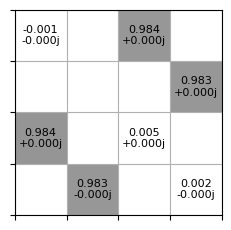

In [12]:
mw.visualize(S_sub_p)

### 6.7 Convergence with number of modes

The interface S-matrix is a truncated modal expansion. The quality improves as more modes are included (better completeness). Let's check how the key entries converge.

In [13]:
# Convergence: compute S-matrix using first K modes for K = 2, 3, ..., N
results = []
for K in range(2, N + 1):
    mL_k = modes_left[:K]
    mR_k = modes_right[:K]
    O_lr_k = overlap_matrix(mL_k, mR_k, ip)
    O_rl_k = overlap_matrix(mR_k, mL_k, ip)
    I_k = np.eye(K)

    # Compute all 4 blocks (using stable averaged R formulation)
    A_lr_k = O_lr_k + O_rl_k.T
    T_lr_k = np.linalg.solve(A_lr_k.T, 2.0 * I_k).T
    R_ll_k = 0.5 * ((O_rl_k.T @ T_lr_k - I_k) + (I_k - O_lr_k @ T_lr_k))

    A_rl_k = O_rl_k + O_lr_k.T
    T_rl_k = np.linalg.solve(A_rl_k.T, 2.0 * I_k).T
    R_rr_k = 0.5 * ((O_lr_k.T @ T_rl_k - I_k) + (I_k - O_rl_k @ T_rl_k))

    # Full S-matrix, then SVD passivity correction
    S_k = np.block(
        [
            [R_ll_k, T_rl_k],
            [T_lr_k, R_rr_k],
        ]
    )
    U_k, s_k, Vh_k = np.linalg.svd(S_k, full_matrices=False)
    S_k_p = (U_k * enforce_passivity(s_k)) @ Vh_k
    T_lr_p_k = S_k_p[K:, :K]
    R_ll_p_k = S_k_p[:K, :K]
    results.append(
        (
            K,
            abs(T_lr_k[0, 0]),
            abs(R_ll_k[0, 0]),
            abs(T_lr_p_k[0, 0]),
            abs(R_ll_p_k[0, 0]),
        )
    )

Ks, Ts, Rs, Ts_p, Rs_p = zip(*results)
ref_T = abs(S_ref[N_ref, 0])
ref_R = abs(S_ref[0, 0])

/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/3685034045.py:27: RuntimeWarning: divide by zero encountered in matmul
  S_k_p = (U_k * enforce_passivity(s_k)) @ Vh_k
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/3685034045.py:27: RuntimeWarning: overflow encountered in matmul
  S_k_p = (U_k * enforce_passivity(s_k)) @ Vh_k
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/3685034045.py:27: RuntimeWarning: invalid value encountered in matmul
  S_k_p = (U_k * enforce_passivity(s_k)) @ Vh_k
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/3685034045.py:13: RuntimeWarning: divide by zero encountered in matmul
  R_ll_k = 0.5 * ((O_rl_k.T @ T_lr_k - I_k) + (I_k - O_lr_k @ T_lr_k))
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/T/ipykernel_43439/3685034045.py:13: RuntimeWarning: overflow encountered in matmul
  R_ll_k = 0.5 * ((O_rl_k.T @ T_lr_k - I_k) + (I_k - O_lr_k @ T_lr_k))
/var/folders/_y/nld7tqgn3332lg3mfjr6c8qw0000gn/

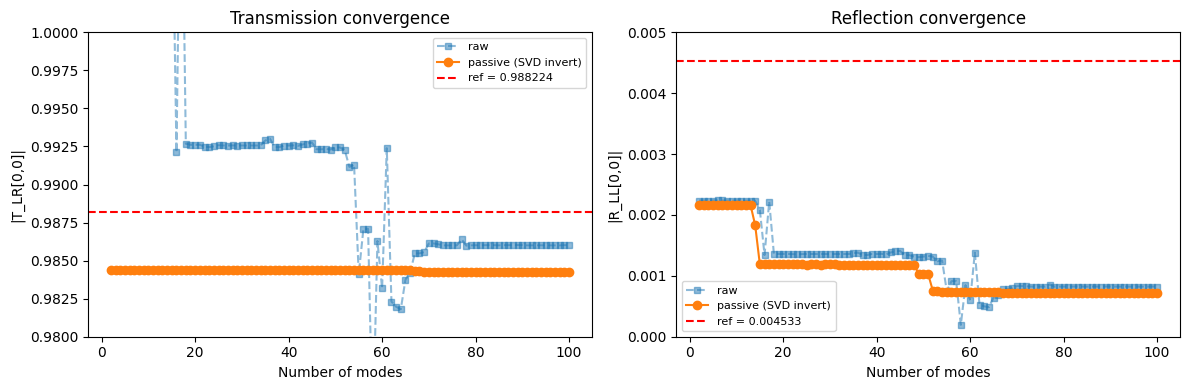

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(Ks, Ts, "s--", alpha=0.5, label="raw", markersize=4)
ax1.plot(Ks, Ts_p, "o-", label="passive (SVD invert)")
ax1.axhline(ref_T, color="r", ls="--", label=f"ref = {ref_T:.6f}")
ax1.set_xlabel("Number of modes")
ax1.set_ylabel("|T_LR[0,0]|")
ax1.legend(fontsize=8)
ax1.set_title("Transmission convergence")
ax1.set_ylim(0.98, 1.00)

ax2.plot(Ks, Rs, "s--", alpha=0.5, label="raw", markersize=4)
ax2.plot(Ks, Rs_p, "o-", label="passive (SVD invert)")
ax2.axhline(ref_R, color="r", ls="--", label=f"ref = {ref_R:.6f}")
ax2.set_xlabel("Number of modes")
ax2.set_ylabel("|R_LL[0,0]|")
ax2.legend(fontsize=8)
ax2.set_title("Reflection convergence")
ax2.set_ylim(0.00, 0.005)


plt.tight_layout()
plt.show()

## 7. Discussion

### What changed vs. previous notebooks

| Issue | Previous notebooks | This notebook |
|-------|-------------------|---------------|
| Inner product | `symmetric=True` (default) | `symmetric=False` |
| Reflection | $R = 0$ always (algebraic) | $R \neq 0$ (physical) |
| Orthonormalization | Commented out | Enabled |
| Same-medium $T$ | $\|T - I\| \approx 0.27$ | $\|T - I\| \approx 0$ |
| Metric factors | Needed (workaround for $G \neq I$) | Not needed ($G = I$) |
| Passivity | SVD clipping | SVD inversion (default) |

### Why `symmetric=False` is essential

The symmetric inner product $\frac{1}{4}[(E_a \times H_b) + (E_b \times H_a)] \cdot \hat{z}$ is
commutative by construction, forcing $O_{LR} = O_{RL}^T$ for **any** pair of modes from **any** two
waveguides. This algebraically kills $R = \frac{1}{2}(O_{RL}^T - O_{LR}) T = 0$.

The asymmetric product $\frac{1}{2}(E_a \times H_b) \cdot \hat{z}$ breaks this symmetry
across different waveguides. Lorentz reciprocity only guarantees symmetry *within* the same
waveguide ($G_{LL} = G_{LL}^T$), not across ($O_{LR} \neq O_{RL}^T$).

### On the metric

With orthonormalized modes, $G_{LL} = G_{RR} = I$ and the metric factors vanish.
The simple thesis formulas work directly. The generalized formulas
$T = 2(O + O^T)^{-1} G$ are needed only when modes are not orthonormalized.

**Note**: for same-waveguide modes, the asymmetric and symmetric products are identical
(Lorentz reciprocity), so modes normalized under either convention are interchangeable.

### Passivity and the truncation effect

With a **complete** modal basis, the interface formulas yield a unitary S-matrix (energy conservation).
With a **truncated** basis, the S-matrix can violate passivity ($\sigma_{\max} > 1$).

**Why does truncation cause $|T| > 1$?** Consider the scalar (single-mode) case. With complete
bases, the overlap integrals satisfy $o_{LR} + o_{RL} = 2$ (completeness), giving
$T = 2/(o_{LR} + o_{RL}) = 1$ and $|T| \leq 1$ by AM-GM. With truncated bases, both
$o_{LR}$ and $o_{RL}$ are reduced (the missing radiation modes that would contribute to the sum
are absent), so $o_{LR} + o_{RL} < 2$ and $T = 2/(o_{LR} + o_{RL}) > 1$.

For the multi-mode case, the same mechanism operates on each singular component of the overlap
matrices. The diagonal elements of $(O_{LR} + O_{RL}^T)$ are each a sum of two overlap integrals
that are reduced by truncation. When this matrix is diagonally dominant (as is typical for
well-ordered guided modes), the diagonal entries control the singular values of $T$, and the
scalar reasoning carries over approximately to each diagonal element.

### Why inversion instead of clipping?

The standard EME fix is to clip singular values to $\leq 1$. However, **inversion** ($\sigma \to 1/\sigma$
for $\sigma > 1$) is more physically motivated:

If $T_{ii} = 1 + \varepsilon$ (over-complete), the excess $\varepsilon$ represents power that should
couple to uncomputed radiation modes. But those modes would *remove* power from the guided channel,
so the true $T_{ii} \approx 1 - \varepsilon$. The error is **symmetric around 1**.

For $\sigma = 1 + \varepsilon$:
- Clipping: $\sigma \to 1$ (ignores radiation loss)
- Inversion: $\sigma \to 1/\sigma \approx 1 - \varepsilon$ (accounts for radiation loss)

Inversion produces a **lossy** S-matrix that correctly reflects power escaping to uncomputed modes,
rather than pretending the system is lossless. It's also numerically safe: $1/\sigma \in (0, 1]$
for any $\sigma \geq 1$, gracefully suppressing severely over-complete channels.

### Note on the passivity check

We check passivity via $\sigma(S) \leq 1$, i.e., $S^\dagger S \leq I$. Strictly, this is the
correct power-conservation criterion only when the S-matrix maps between orthonormal bases
with respect to the **power** inner product $\frac{1}{2}\text{Re}\int (E \times H^*)\cdot\hat{z}\,dA$.
In this notebook, our modes are real-valued (lossless dielectrics with real refractive index),
so the unconjugated product $\frac{1}{2}\int (E \times H)\cdot\hat{z}\,dA$ coincides with the
conjugated power product. For lossy or complex-$n$ geometries with complex-valued modes, one
would need to check $S^\dagger G S \leq G$ where $G$ is the power-metric Gram matrix.

### Discrepancies with the reference

The remaining differences between this computation and `s_ref.npy` arise from:

1. **Modal completeness**: with $N$ modes on a 101×101 mesh with PML,
   radiation modes are better represented than without PML, but still incomplete.

2. **Reflection magnitude**: our $|R|$ may differ from reference due to
   sensitivity of $O_{RL}^T - O_{LR}$ (small difference of nearly-equal matrices)
   to mode profile accuracy (mesh resolution, PML parameters, solver numerics).

3. **Reference solver**: the reference likely uses a different modal basis
   (different PML, mesh resolution, or a variational/energy-conserving formulation).

The **transmission** $|T_{LR}[0,0]|$ typically agrees well after passivity correction —
the dominant physics is captured correctly. The **reflection** is a second-order effect
that requires higher numerical accuracy to resolve precisely.